# EDA — credit_card_balance.csv

## Step 1 — Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
print("Libraries loaded")

Libraries loaded


## Step 2 — Load Data

In [6]:
df = pd.read_csv("data/application_train.csv")
df.columns = df.columns.str.lower().str.strip()
if "target" in df.columns:
    df = df.rename(columns={"target": "default"})

cc = pd.read_csv("data/credit_card_balance.csv")
cc.columns = cc.columns.str.lower().str.strip()

print("application_train shape  :", df.shape)
print("credit_card_balance shape:", cc.shape)

application_train shape  : (307511, 122)
credit_card_balance shape: (3840312, 23)


## Step 3 

In [8]:
cc.head()

,sk_id_prev,sk_id_curr,months_balance,amt_balance,amt_credit_limit_actual,amt_drawings_atm_current,amt_drawings_current,amt_drawings_other_current,amt_drawings_pos_current,amt_inst_min_regularity,amt_payment_current,amt_payment_total_current,amt_receivable_principal,amt_recivable,amt_total_receivable,cnt_drawings_atm_current,cnt_drawings_current,cnt_drawings_other_current,cnt_drawings_pos_current,cnt_instalment_mature_cum,name_contract_status,sk_dpd,sk_dpd_def
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,1800.0,1800.0,0.000,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,2250.0,2250.0,60175.080,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,2250.0,2250.0,26926.425,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,11925.0,11925.0,224949.285,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,27000.0,27000.0,443044.395,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


In [9]:
print("=== COLUMNS ===")
print(cc.columns.tolist())
print()
print("=== DATA TYPES ===")
print(cc.dtypes.value_counts())

=== COLUMNS ===
['sk_id_prev', 'sk_id_curr', 'months_balance', 'amt_balance', 'amt_credit_limit_actual', 'amt_drawings_atm_current', 'amt_drawings_current', 'amt_drawings_other_current', 'amt_drawings_pos_current', 'amt_inst_min_regularity', 'amt_payment_current', 'amt_payment_total_current', 'amt_receivable_principal', 'amt_recivable', 'amt_total_receivable', 'cnt_drawings_atm_current', 'cnt_drawings_current', 'cnt_drawings_other_current', 'cnt_drawings_pos_current', 'cnt_instalment_mature_cum', 'name_contract_status', 'sk_dpd', 'sk_dpd_def']

=== DATA TYPES ===
float64    15
int64       7
object      1
Name: count, dtype: int64


## Step 4 — Basic Statistics

In [11]:
cc.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
sk_id_prev,3840312.0,1904503.59,536469.47,1000018.00,1434385.00,1897122.0,2369327.75,2843496.00
sk_id_curr,3840312.0,278324.21,102704.48,100006.00,189517.00,278396.0,367580.00,456250.00
months_balance,3840312.0,-34.52,26.67,-96.00,-55.00,-28.0,-11.00,-1.00
amt_balance,3840312.0,58300.16,106307.03,-420250.18,0.00,0.0,89046.69,1505902.18
amt_credit_limit_actual,3840312.0,153807.96,165145.70,0.00,45000.00,112500.0,180000.00,1350000.00
amt_drawings_atm_current,3090496.0,5961.32,28225.69,-6827.31,0.00,0.0,0.00,2115000.00
amt_drawings_current,3840312.0,7433.39,33846.08,-6211.62,0.00,0.0,0.00,2287098.32
amt_drawings_other_current,3090496.0,288.17,8201.99,0.00,0.00,0.0,0.00,1529847.00
amt_drawings_pos_current,3090496.0,2968.80,20796.89,0.00,0.00,0.0,0.00,2239274.16
amt_inst_min_regularity,3535076.0,3540.20,5600.15,0.00,0.00,0.0,6633.91,202882.00


## Step 5 — Records Per Applicant

In [13]:
print("Unique applicants      :", cc["sk_id_curr"].nunique())
print("Unique previous loans  :", cc["sk_id_prev"].nunique())
print("Average records/person :", round(
    len(cc) / cc["sk_id_curr"].nunique(), 2))

Unique applicants      : 103558
Unique previous loans  : 104307
Average records/person : 37.08


count    103558.00
mean         37.08
std          33.48
min           1.00
25%          10.00
50%          22.00
75%          75.00
max         192.00
Name: sk_id_prev, dtype: float64


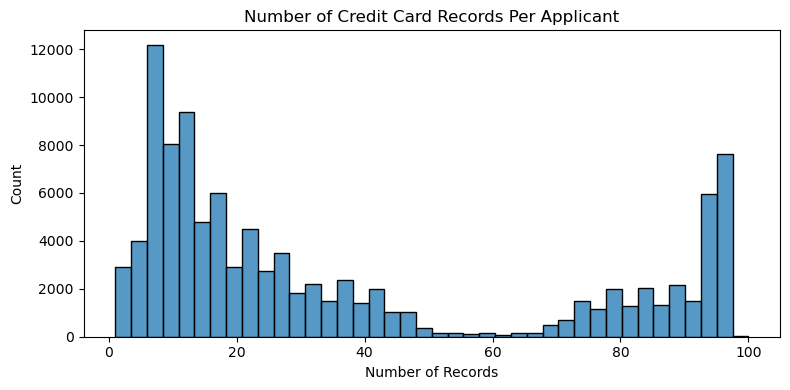

In [14]:
records_per_person = cc.groupby("sk_id_curr")["sk_id_prev"].count()

print(records_per_person.describe().round(2))

plt.figure(figsize=(8, 4))
sns.histplot(records_per_person[records_per_person <= 100], bins=40)
plt.title("Number of Credit Card Records Per Applicant")
plt.xlabel("Number of Records")
plt.tight_layout()
plt.show()

## Step 6 — Missing Values

Columns with missing values: 9

amt_payment_current           20.00
amt_drawings_atm_current      19.52
amt_drawings_other_current    19.52
amt_drawings_pos_current      19.52
cnt_drawings_atm_current      19.52
cnt_drawings_other_current    19.52
cnt_drawings_pos_current      19.52
amt_inst_min_regularity        7.95
cnt_instalment_mature_cum      7.95
dtype: float64


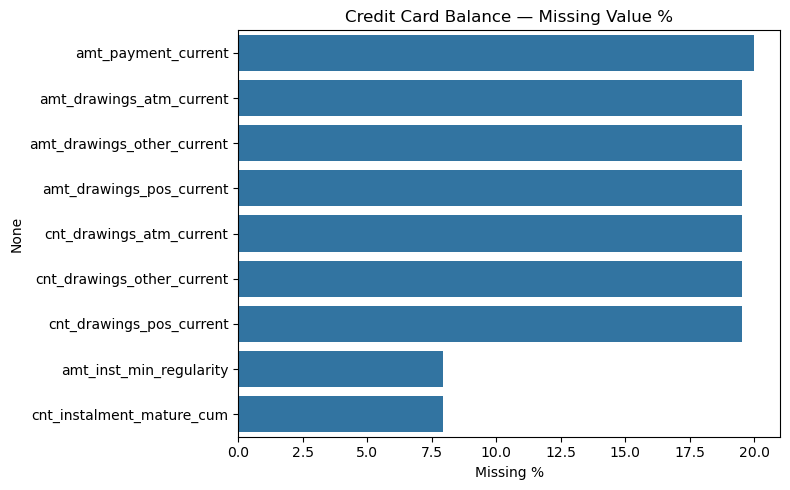

In [16]:
missing_cc = (cc.isnull().sum() / len(cc) * 100).round(2)
missing_cc = missing_cc[missing_cc > 0].sort_values(ascending=False)

print("Columns with missing values:", len(missing_cc))
print()
print(missing_cc)

plt.figure(figsize=(8, 5))
sns.barplot(x=missing_cc.values, y=missing_cc.index)
plt.title("Credit Card Balance — Missing Value %")
plt.xlabel("Missing %")
plt.tight_layout()
plt.show()

## Step 7 — Distribution of Key Columns

=== CONTRACT STATUS ===
name_contract_status
Active           3698436
Completed         128918
Signed             11058
Demand              1365
Sent proposal        513
Refused               17
Approved               5
Name: count, dtype: int64

name_contract_status
Active           96.31
Completed         3.36
Signed            0.29
Demand            0.04
Sent proposal     0.01
Refused           0.00
Approved          0.00
Name: proportion, dtype: float64


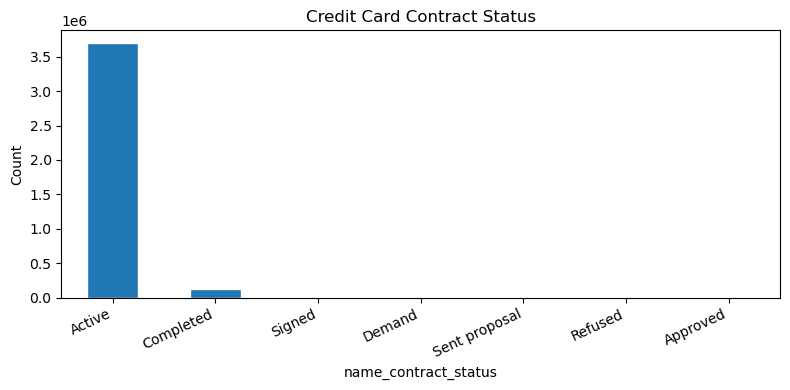

In [18]:
print("=== CONTRACT STATUS ===")
print(cc["name_contract_status"].value_counts())
print()
print((cc["name_contract_status"].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(8, 4))
cc["name_contract_status"].value_counts().plot(kind="bar", edgecolor="white")
plt.title("Credit Card Contract Status")
plt.ylabel("Count")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

=== BALANCE ===
count    3840312.00
mean       58300.16
std       106307.03
min      -420250.18
25%            0.00
50%            0.00
75%        89046.69
max      1505902.18
Name: amt_balance, dtype: float64


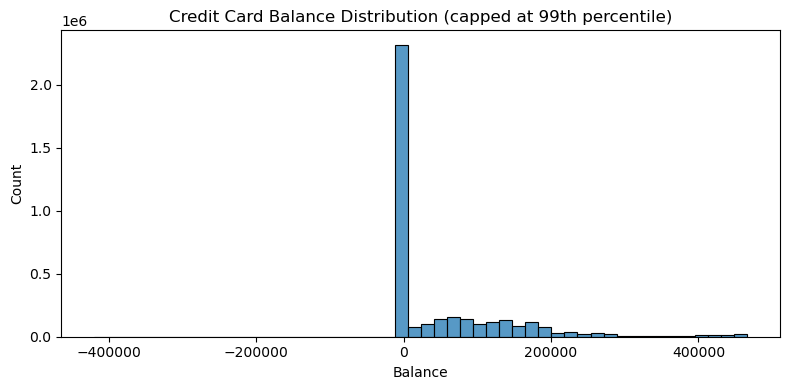

In [19]:
print("=== BALANCE ===")
print(cc["amt_balance"].describe().round(2))

q99 = cc["amt_balance"].quantile(0.99)
plt.figure(figsize=(8, 4))
sns.histplot(cc[cc["amt_balance"] <= q99]["amt_balance"], bins=50)
plt.title("Credit Card Balance Distribution (capped at 99th percentile)")
plt.xlabel("Balance")
plt.tight_layout()
plt.show()

=== CREDIT LIMIT ===
count    3840312.00
mean      153807.96
std       165145.70
min            0.00
25%        45000.00
50%       112500.00
75%       180000.00
max      1350000.00
Name: amt_credit_limit_actual, dtype: float64


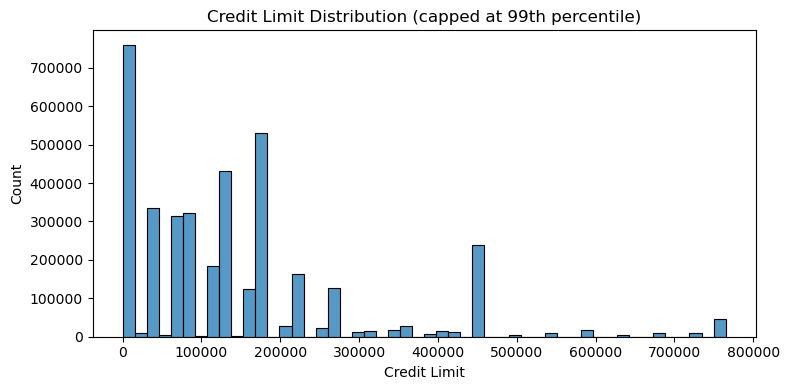

In [20]:
print("=== CREDIT LIMIT ===")
print(cc["amt_credit_limit_actual"].describe().round(2))

q99_cl = cc["amt_credit_limit_actual"].quantile(0.99)
plt.figure(figsize=(8, 4))
sns.histplot(
    cc[cc["amt_credit_limit_actual"] <= q99_cl]["amt_credit_limit_actual"],
    bins=50
)
plt.title("Credit Limit Distribution (capped at 99th percentile)")
plt.xlabel("Credit Limit")
plt.tight_layout()
plt.show()

In [21]:
print("=== DAYS PAST DUE (sk_dpd) ===")
print(cc["sk_dpd"].describe().round(2))

dpd = (cc["sk_dpd"] > 0).sum()
print()
print("Records with any DPD:", dpd,
      f"({round(dpd / len(cc) * 100, 2)}%)")

print()
print("=== DAYS PAST DUE DEF (sk_dpd_def) ===")
print(cc["sk_dpd_def"].describe().round(2))

=== DAYS PAST DUE (sk_dpd) ===
count    3840312.00
mean           9.28
std           97.52
min            0.00
25%            0.00
50%            0.00
75%            0.00
max         3260.00
Name: sk_dpd, dtype: float64

Records with any DPD: 153355 (3.99%)

=== DAYS PAST DUE DEF (sk_dpd_def) ===
count    3840312.00
mean           0.33
std           21.48
min            0.00
25%            0.00
50%            0.00
75%            0.00
max         3260.00
Name: sk_dpd_def, dtype: float64


In [22]:
print("=== DRAWINGS ===")
print()
print("Total drawings:")
print(cc["amt_drawings_current"].describe().round(2))
print()
print("ATM drawings:")
print(cc["amt_drawings_atm_current"].describe().round(2))
print()
print("POS drawings:")
print(cc["amt_drawings_pos_current"].describe().round(2))

=== DRAWINGS ===

Total drawings:
count    3840312.00
mean        7433.39
std        33846.08
min        -6211.62
25%            0.00
50%            0.00
75%            0.00
max      2287098.32
Name: amt_drawings_current, dtype: float64

ATM drawings:
count    3090496.00
mean        5961.32
std        28225.69
min        -6827.31
25%            0.00
50%            0.00
75%            0.00
max      2115000.00
Name: amt_drawings_atm_current, dtype: float64

POS drawings:
count    3090496.00
mean        2968.80
std        20796.89
min            0.00
25%            0.00
50%            0.00
75%            0.00
max      2239274.16
Name: amt_drawings_pos_current, dtype: float64


=== MONTHS BALANCE ===
0   = current month
-96 = 8 years ago

count    3840312.00
mean         -34.52
std           26.67
min          -96.00
25%          -55.00
50%          -28.00
75%          -11.00
max           -1.00
Name: months_balance, dtype: float64


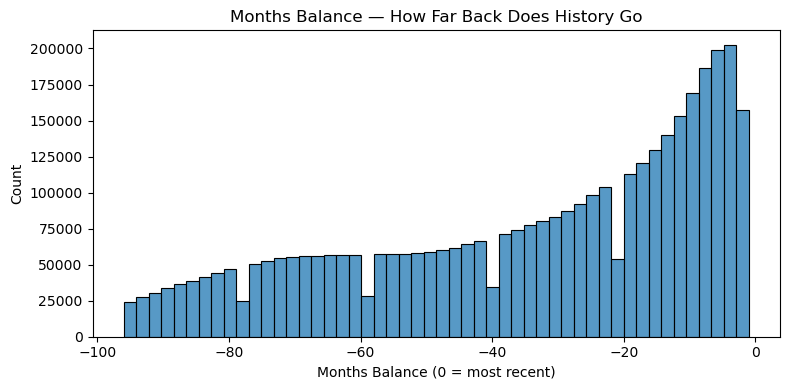

In [23]:
print("=== MONTHS BALANCE ===")
print("0   = current month")
print("-96 = 8 years ago")
print()
print(cc["months_balance"].describe().round(2))

plt.figure(figsize=(8, 4))
sns.histplot(cc["months_balance"], bins=50)
plt.title("Months Balance — How Far Back Does History Go")
plt.xlabel("Months Balance (0 = most recent)")
plt.tight_layout()
plt.show()

## Step 8 — Coverage Against Main Dataset

In [25]:
main_ids = set(df["sk_id_curr"])
cc_ids   = set(cc["sk_id_curr"])

matched  = len(main_ids & cc_ids)
no_match = len(main_ids - cc_ids)

print("Have credit card records:", matched,
      f"({round(matched / len(main_ids) * 100, 2)}%)")
print("No credit card records  :", no_match,
      f"({round(no_match / len(main_ids) * 100, 2)}%)")

has_cc = df[df["sk_id_curr"].isin(cc_ids)]
no_cc  = df[~df["sk_id_curr"].isin(cc_ids)]

print()
print("Default rate WITH credit card records:",
      round(has_cc["default"].mean() * 100, 2), "%")
print("Default rate WITHOUT records         :",
      round(no_cc["default"].mean() * 100, 2), "%")

Have credit card records: 86905 (28.26%)
No credit card records  : 220606 (71.74%)

Default rate WITH credit card records: 8.67 %
Default rate WITHOUT records         : 7.84 %


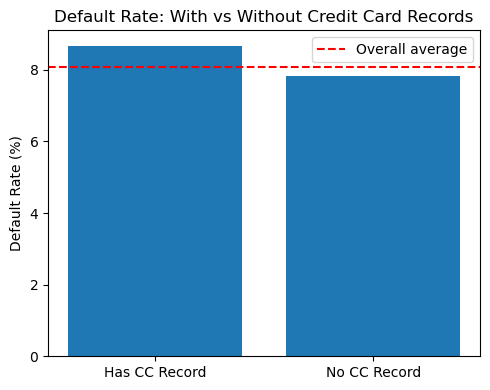

In [26]:
plt.figure(figsize=(5, 4))
plt.bar(
    ["Has CC Record", "No CC Record"],
    [has_cc["default"].mean() * 100,
     no_cc["default"].mean() * 100]
)
plt.title("Default Rate: With vs Without Credit Card Records")
plt.ylabel("Default Rate (%)")
plt.axhline(df["default"].mean() * 100, color="red",
            linestyle="--", label="Overall average")
plt.legend()
plt.tight_layout()
plt.show()

## Step 9 — Relationship with Target

In [28]:
cc_agg = cc.groupby("sk_id_curr").agg(
    cc_months_count     = ("months_balance", "count"),
    cc_avg_balance      = ("amt_balance", "mean"),
    cc_max_balance      = ("amt_balance", "max"),
    cc_avg_credit_limit = ("amt_credit_limit_actual", "mean"),
    cc_avg_dpd          = ("sk_dpd", "mean"),
    cc_max_dpd          = ("sk_dpd", "max"),
    cc_dpd_rate         = ("sk_dpd", lambda x: (x > 0).sum() / len(x)),
    cc_avg_drawings     = ("amt_drawings_current", "mean"),
    cc_avg_payment      = ("amt_payment_total_current", "mean"),
).reset_index()

print("Credit card aggregated shape:", cc_agg.shape)
print()
print(cc_agg.head())

Credit card aggregated shape: (103558, 10)

   sk_id_curr  cc_months_count  cc_avg_balance  cc_max_balance  \
0      100006                6        0.000000            0.00   
1      100011               74    54482.111149       189000.00   
2      100013               96    18159.919219       161420.22   
3      100021               17        0.000000            0.00   
4      100023                8        0.000000            0.00   

   cc_avg_credit_limit  cc_avg_dpd  cc_max_dpd  cc_dpd_rate  cc_avg_drawings  \
0        270000.000000    0.000000           0     0.000000         0.000000   
1        164189.189189    0.000000           0     0.000000      2432.432432   
2        131718.750000    0.010417           1     0.010417      5953.125000   
3        675000.000000    0.000000           0     0.000000         0.000000   
4        135000.000000    0.000000           0     0.000000         0.000000   

   cc_avg_payment  
0        0.000000  
1     4520.067568  
2     6817.172344 

=== CREDIT CARD FEATURES — CORRELATION WITH DEFAULT ===
cc_months_count       -0.0605
cc_avg_credit_limit   -0.0089
cc_max_dpd            -0.0060
cc_avg_dpd            -0.0032
cc_dpd_rate            0.0018
cc_avg_payment         0.0227
cc_avg_drawings        0.0587
cc_max_balance         0.0688
cc_avg_balance         0.0872
Name: default, dtype: float64


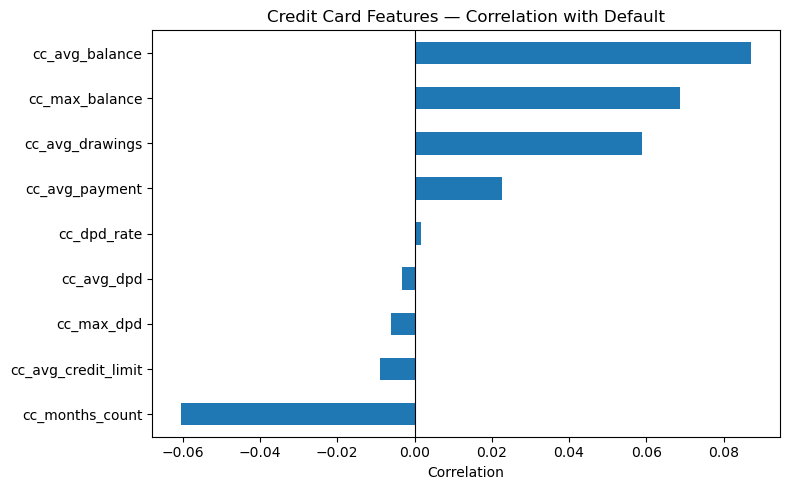

In [29]:
df_cc = df.merge(cc_agg, on="sk_id_curr", how="left")

cc_feat_cols = [c for c in cc_agg.columns if c != "sk_id_curr"]
corr_cc = df_cc[cc_feat_cols + ["default"]].corr()["default"].drop("default")

print("=== CREDIT CARD FEATURES — CORRELATION WITH DEFAULT ===")
print(corr_cc.sort_values().round(4))

plt.figure(figsize=(8, 5))
corr_cc.sort_values().plot(kind="barh")
plt.title("Credit Card Features — Correlation with Default")
plt.xlabel("Correlation")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## Step 10 — Outlier Check

In [31]:
cc_num  = cc.select_dtypes(include=np.number).columns.tolist()
excl_cc = ["sk_id_prev", "sk_id_curr", "months_balance"]
check_cc = [c for c in cc_num if c not in excl_cc]

print(f"Checking {len(check_cc)} columns\n")
print(f"{'Column':<35} {'1%':>12} {'99%':>12} {'Max':>15} {'Outlier?'}")
print("-" * 85)

outliers_cc = []
for col in check_cc:
    q01     = cc[col].quantile(0.01)
    q99     = cc[col].quantile(0.99)
    max_val = cc[col].max()
    is_out  = (max_val > q99 * 3) if q99 > 0 else (
               max_val > 100 if q99 == 0 else False)
    flag    = "YES" if is_out else "ok"
    if is_out:
        outliers_cc.append(col)
    print(f"{col:<35} {q01:>12.2f} {q99:>12.2f} {max_val:>15.2f}  {flag}")

print()
print("Outlier columns:")
for c in outliers_cc:
    print(" -", c)

Checking 19 columns

Column                                        1%          99%             Max Outlier?
-------------------------------------------------------------------------------------
amt_balance                                 0.00    466295.12      1505902.19  YES
amt_credit_limit_actual                     0.00    765000.00      1350000.00  ok
amt_drawings_atm_current                    0.00    135000.00      2115000.00  YES
amt_drawings_current                        0.00    157500.00      2287098.31  YES
amt_drawings_other_current                  0.00         0.00      1529847.00  YES
amt_drawings_pos_current                    0.00     77080.61      2239274.16  YES
amt_inst_min_regularity                     0.00     23312.80       202882.01  YES
amt_payment_current                         0.00    150617.43      4289207.45  YES
amt_payment_total_current                   0.00    128614.93      4278315.69  YES
amt_receivable_principal                    0.00    448121.8

## Observations

- 3,840,312 records, 23 columns.
- Average credit card records per applicant needs checking.
- Only 28.26% of main dataset applicants have credit card records — low coverage.
- This is the key reason for potentially excluding this dataset.
- Low coverage means 72% of applicants get NaN for all credit card features.
- Some missing values in drawing-related columns — around 20%.
- sk_dpd shows days past due per month — most records show zero.
- Credit balance and credit limit show wide distributions.
- History goes back up to 96 months (8 years) like bureau_balance.